# Feature importance plots: Random Forest vs XGBoost

Reads the per-model importance CSVs from `../data/feature_importance/` and produces two figures:

1. **Grouped comparison** — a single horizontal bar chart with both models side by side, sorted by mean importance.
2. **Two side-by-side panels** — each model independently sorted on its own importances.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fi_dir = "../data/feature_importance"
results_dir = "../results/"
rf = pd.read_csv(f"{fi_dir}/RF_feature_importance_final.csv")
xgb = pd.read_csv(f"{fi_dir}/XGB_feature_importance_final.csv")

## Version 1 — grouped comparison (single figure)

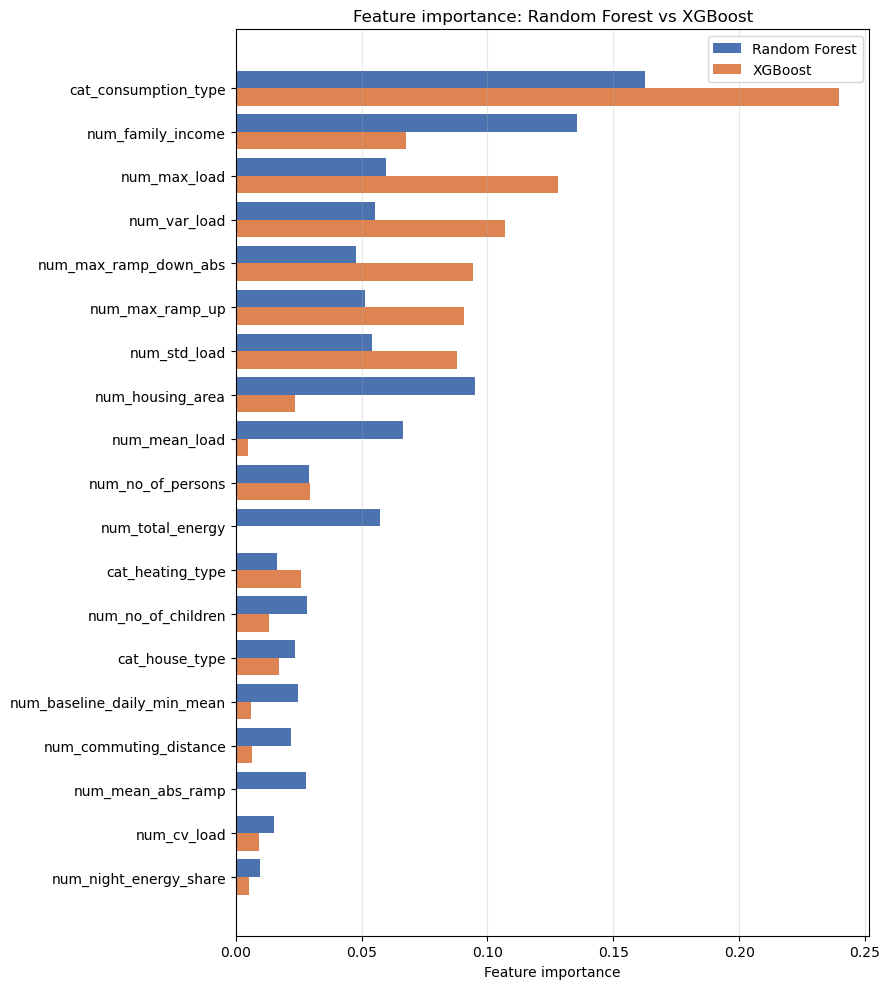

In [4]:
# merge on feature; outer keeps features present in only one model
df = rf.merge(xgb, on="feature", how="outer").fillna(0)
df["mean_imp"] = df[["RF_importance", "XGB_importance"]].mean(axis=1)
df = df.sort_values("mean_imp", ascending=True)  # ascending -> largest on top in barh

y = np.arange(len(df))
h = 0.4
plt.figure(figsize=(9, 10))
plt.barh(y + h/2, df["RF_importance"],  height=h, label="Random Forest", color="#4C72B0")
plt.barh(y - h/2, df["XGB_importance"], height=h, label="XGBoost",       color="#DD8452")
plt.yticks(y, df["feature"])
plt.xlabel("Feature importance")
plt.title("Feature importance: Random Forest vs XGBoost")
plt.legend()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_dir}/RFvsXGB_feature_importance_final.png", dpi=300, bbox_inches="tight")
plt.show()

## Version 2 — two side-by-side horizontal bar charts

Each model independently sorted on its own importances (so the top feature sits on top for each, even when the rankings differ).

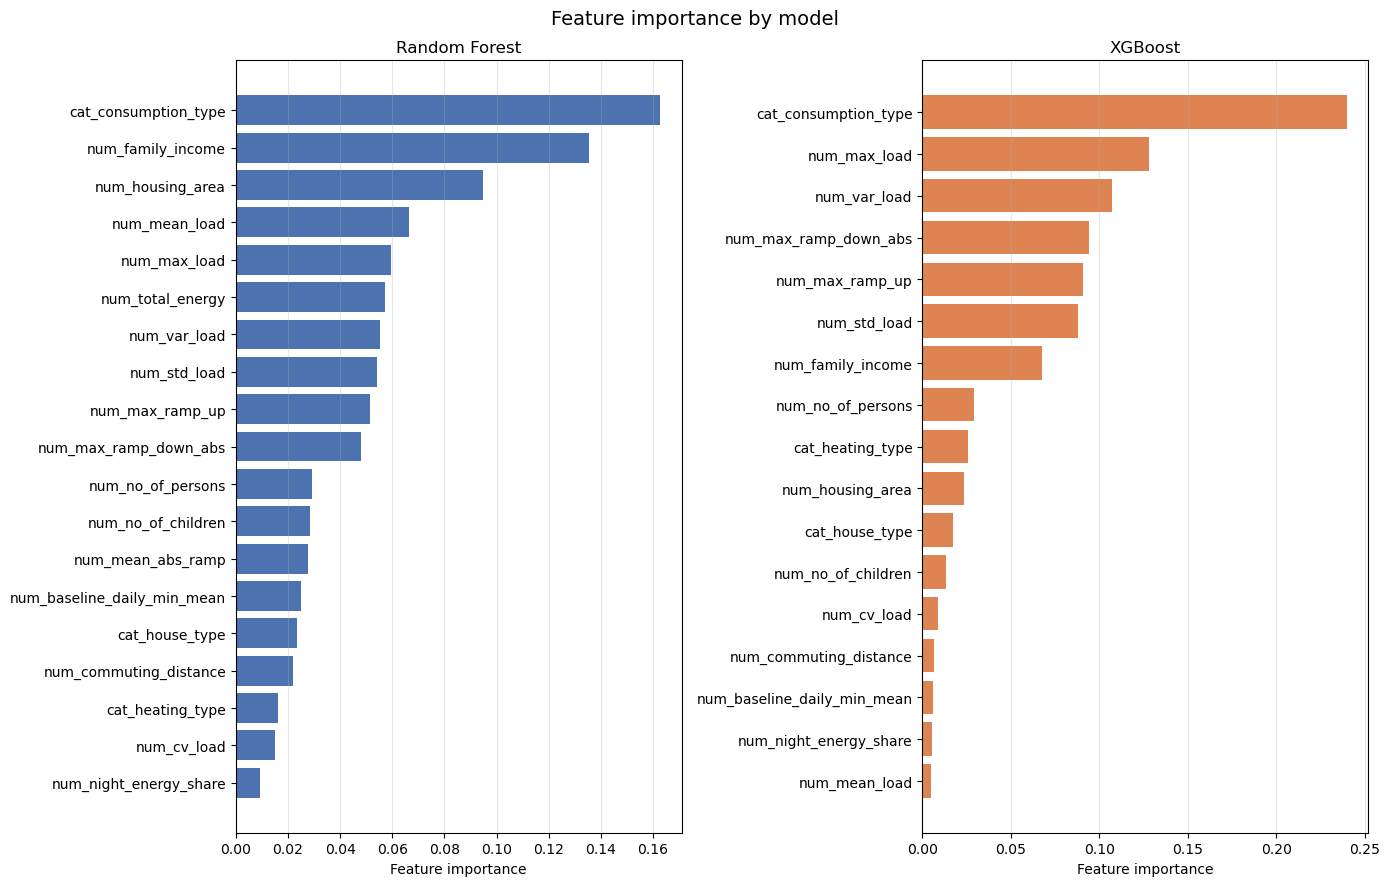

In [5]:
rf_sorted = rf.sort_values("RF_importance")
xgb_sorted = xgb.sort_values("XGB_importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# Random Forest
axes[0].barh(rf_sorted["feature"], rf_sorted["RF_importance"], color="#4C72B0")
axes[0].set_xlabel("Feature importance")
axes[0].set_title("Random Forest")
axes[0].grid(True, axis="x", alpha=0.3)

# XGBoost
axes[1].barh(xgb_sorted["feature"], xgb_sorted["XGB_importance"], color="#DD8452")
axes[1].set_xlabel("Feature importance")
axes[1].set_title("XGBoost")
axes[1].grid(True, axis="x", alpha=0.3)

fig.suptitle("Feature importance by model", fontsize=14)
fig.tight_layout()
fig.savefig(f"{results_dir}/RFvsXGB_feature_importance_sidebyside_final.png", dpi=300, bbox_inches="tight")
plt.show()